# Task 1: 单比特 RX 态制备与 Rabi 振荡

这个 notebook 按 `examples/noise_simulation_tests/task2, task4, task5` 的方式组织：同目录下有 `task.yaml`, `device.yaml`, `pulse.yaml`, `solver.yaml`, `analyser.yaml`，这里通过 `musiq.workflow.create_model()` 跑模型。

任务只包含一个 transmon 比特 `q0` 和一个参数化 `rx(theta)` 门。我们扫描 `theta`，并把它解释为等效门时间 `t = theta / pi * t_pi`。当前 report 版本使用三能级 `nlevel` 模型 and 方波 `rect` 脉冲，因此除了 `P0/P1` 的 Rabi 振荡，也可以观察 `P2` leakage。

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from musiq.pulse.sequence import PulseCompiler
from musiq.workflow import create_model, load_config


MODEL_DIR = Path(".")
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

def target_rx_state(theta):
    return np.array([np.cos(theta / 2), -1j * np.sin(theta / 2), 0.0], dtype=complex)


## 1. 先跑一个 RX(π) 模型

`task.yaml` 默认绑定 `theta = π`，也就是一个 X 翻转。这里先跑一次，确认 solver/analyser 输出和 examples 里的任务一致。

In [2]:
model = create_model(
    circuits=MODEL_DIR / "circuit.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser.yaml",
)
model.run_all()

analysis = model.analyses["case_0"]
print("solver keys =", sorted(model.solvers.keys()))
print("runs keys =", sorted(model.runs.keys()))
print("analysis keys =", sorted(model.analyses.keys()))
print("metric keys =", sorted(analysis.output.metrics.keys()))


solver keys = ['solver_0']
runs keys = ['solver_0']
analysis keys = ['case_0']
metric keys = ['coherence_01', 'leakage', 'population']


### 单次脉冲中的 population 演化

看一下 lowering 后的方波 RX 脉冲

下面画默认 `RX(pi)` 的 `P0/P1/P2`。`P2` 是三能级 transmon 模型里的 leakage population。

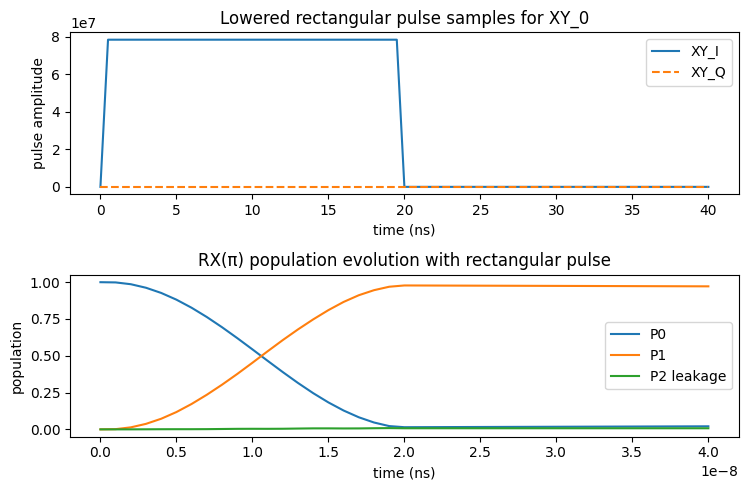

In [3]:
solver_run = model.runs["solver_0"]['single_qubit_rx_rabi']

pulse_ir = solver_run.artifacts.pulse_ir
pulse_ir_full = replace(pulse_ir, t_end_s=solver_run.results['param_0'].trajectories['shot_0'].times[-1])
pulse_samples = PulseCompiler.compile(pulse_ir_full, sample_rate_Hz=1e10)
xy_key = next(key for key in pulse_samples if key.startswith("XY_"))
t_pulse_ns = pulse_samples[xy_key]["t"] * 1e9
y_i = pulse_samples[xy_key]["y"]
y_q = pulse_samples[xy_key].get("y_quadrature", np.zeros_like(y_i))

fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot(2, 1, 1)
ax.plot(t_pulse_ns, y_i, label="XY_I")
ax.plot(t_pulse_ns, y_q, linestyle="--", label="XY_Q")
ax.set_xlabel("time (ns)")
ax.set_ylabel("pulse amplitude")
ax.set_title(f"Lowered rectangular pulse samples for {xy_key}")
ax.legend()


ax = fig.add_subplot(2, 1, 2)
pops = analysis.output.metrics['population']
for key, label in [('0', "P0"), ('1', "P1"), ('2', "P2 leakage")]:
    ax.plot(pops.times, pops.values[key], label=label)
ax.set_xlabel("time (ns)")
ax.set_ylabel("population")
ax.set_title("RX(π) population evolution with rectangular pulse")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "pulse_and_population.png", dpi=600)
plt.show()


## 2. 扫描门时间 / 角度得到 Rabi 曲线

这里复用同一个 `Model`，每次只改 `model.task.input.param_bindings["theta"]`。为了和实验里的门时间语言对齐，取 `t_pi = 20 ns`，把 `theta` 映射成 `t_gate = theta / pi * t_pi`。


### RX 态制备保真度

从 `|0>` 出发，理想目标态是

`|psi(theta)> = cos(theta/2)|0> - i sin(theta/2)|1>`。

三能级模型中目标态第三个分量取 0。这里用 `musiq.analysis.state_fidelity` 对最终密度矩阵和目标纯态求保真度。

In [4]:
import numpy as np
from musiq.workflow import create_model
from musiq.schemas.utils import ParameterSweepConfig, ParameterList

# 1. 设置参数
t_pi_ns = 20.0
# thetas = np.unique(np.concatenate([np.linspace(0.0, 3.0 * np.pi, 30), [np.pi / 2, np.pi]]))
# amp_scales = np.linspace(0.0, 3.0, 30)

gate_time_ns = np.linspace(2.0, 60.0, 30)

# 2. 创建模型并配置参数扫描
model = create_model(
    circuits=MODEL_DIR / "circuit.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser.yaml",
    parameter_sweep={"pulse:gates.rx.duration_ns":gate_time_ns}
)

# 3. 一次性执行 - 系统内部处理扫描
model.run_all()

# 4. 提取结果
analysis = model.analyses["sweep_0"]
sweep_metrics = analysis.output.metrics
sweep_metrics.keys()


dict_keys(['final_P0', 'final_P1', 'final_P2', 'final_fidelity', 'final_coherence_01'])

In [5]:
def find_pulse_durations(gate_time_ns, sweep_metrics):
    p1_values = np.array(sweep_metrics["final_P1"].values)
    
    from scipy.optimize import curve_fit

    def rabi_model(t, t_pi, A, B, C):
        return A * np.sin(np.pi * t / (2 * t_pi) + C)**2 + B

    p0 = [gate_time_ns[np.argmax(p1_values)], np.max(p1_values) - np.min(p1_values), np.min(p1_values), 0.0]
    popt, _ = curve_fit(rabi_model, gate_time_ns, p1_values, p0=p0)
    
    t_pi = popt[0]
    idx_half = np.where(p1_values >= 0.5)[0][0]
    
    if idx_half == 0:
        t_pi_2 = gate_time_ns[0]
    else:
        t0, t1 = gate_time_ns[idx_half-1], gate_time_ns[idx_half]
        p0, p1 = p1_values[idx_half-1], p1_values[idx_half]
        t_pi_2 = t0 + (0.5 - p0) * (t1 - t0) / (p1 - p0)
        
    return t_pi_2, t_pi

t_pi_2, t_pi = find_pulse_durations(gate_time_ns, sweep_metrics)
print(f"Estimated π/2 pulse duration: {t_pi_2:.2f} ns")
print(f"Estimated π pulse duration: {t_pi:.2f} ns")

model_pulse = model.copy(include_results=False)
model_pulse.config.parameter_sweep.parameters['pulse:gates.rx.duration_ns'].values = [t_pi_2, t_pi]
model_pulse.run_all()


Estimated π/2 pulse duration: 11.15 ns
Estimated π pulse duration: 20.04 ns


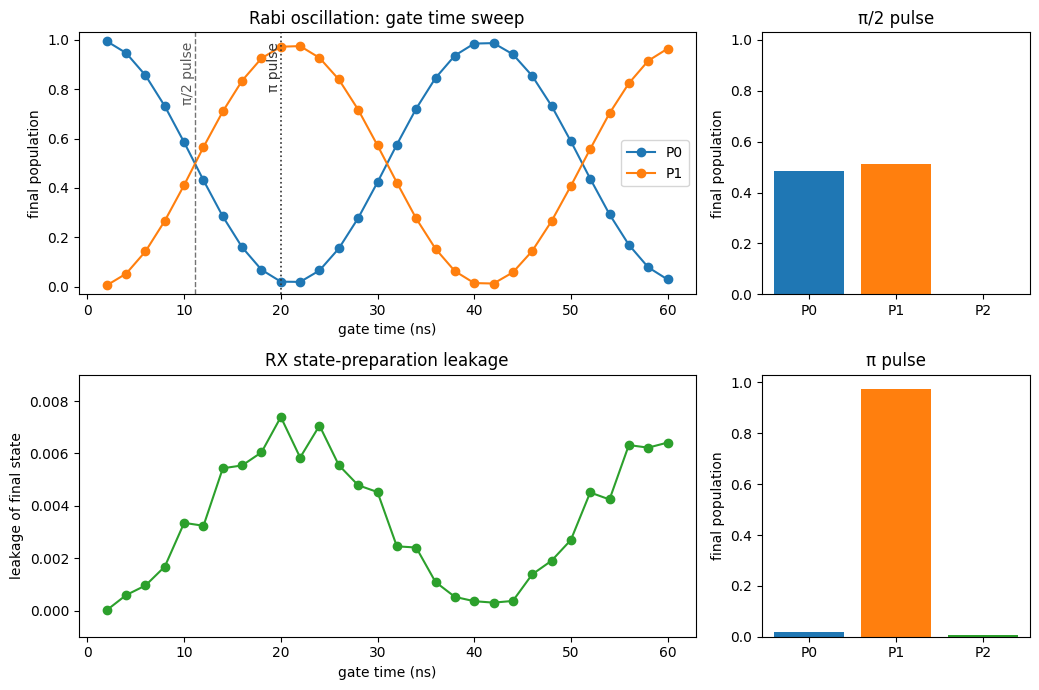

In [6]:
fig = plt.figure(figsize=(10.5, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[2.3, 1.0])

ax = fig.add_subplot(gs[0, 0])
for key, label in [("final_P0", "P0"), ("final_P1", "P1")]:
    ax.plot(gate_time_ns, sweep_metrics[key].values, marker="o", label=label)
ax.axvline(t_pi_2, color="0.45", linestyle="--", linewidth=1.0)
ax.axvline(t_pi, color="0.2", linestyle=":", linewidth=1.2)
ax.text(t_pi_2, 0.99, "π/2 pulse", rotation=90, va="top", ha="right", color="0.35")
ax.text(t_pi, 0.99, "π pulse", rotation=90, va="top", ha="right", color="0.2")
ax.set_xlabel("gate time (ns)")
ax.set_ylabel("final population")
ax.set_title("Rabi oscillation: gate time sweep")
ax.set_ylim(-0.03, 1.03)
ax.legend()

ax = fig.add_subplot(gs[1, 0])
ax.plot(gate_time_ns, sweep_metrics["final_P2"].values, marker="o", color="tab:green")
ax.set_xlabel("gate time (ns)")
ax.set_ylabel("leakage of final state")
ax.set_title("RX state-preparation leakage")
ax.set_ylim(-0.001, 0.009)

for slot, theta, title in [(0, np.pi / 2, "π/2 pulse"), (1, np.pi, "π pulse")]:
    ax_bar = fig.add_subplot(gs[slot, 1])
    ax_bar.bar(["P0", "P1", "P2"], [model_pulse.analyses['sweep_0'].metrics[f].values[slot] for f in ["final_P0", "final_P1", "final_P2"]], color=["tab:blue", "tab:orange", "tab:green"])
    ax_bar.set_title(title)
    ax_bar.set_ylim(0.0, 1.03)
    ax_bar.set_ylabel("final population")
fig.tight_layout()
fig.savefig(FIG_DIR / "model_state_preparation.png", dpi=600)
plt.show()

## 3. 结论

`RX(theta)` 可以把 `|0>` 制备到 Bloch 球的 y-z 大圆上。`theta = pi` 是 `|1>` 制备，`theta = pi/2` 是 `(|0> - i|1>) / sqrt(2)` 制备。扫描 `theta` 并换算为等效门时间后，最终 `P1` 呈现 Rabi 振荡；三能级模型中的 `P2` 展示了方波脉冲可能带来的 leakage，保真度图则给出了每个目标角度相对于理想计算子空间目标态的制备质量。